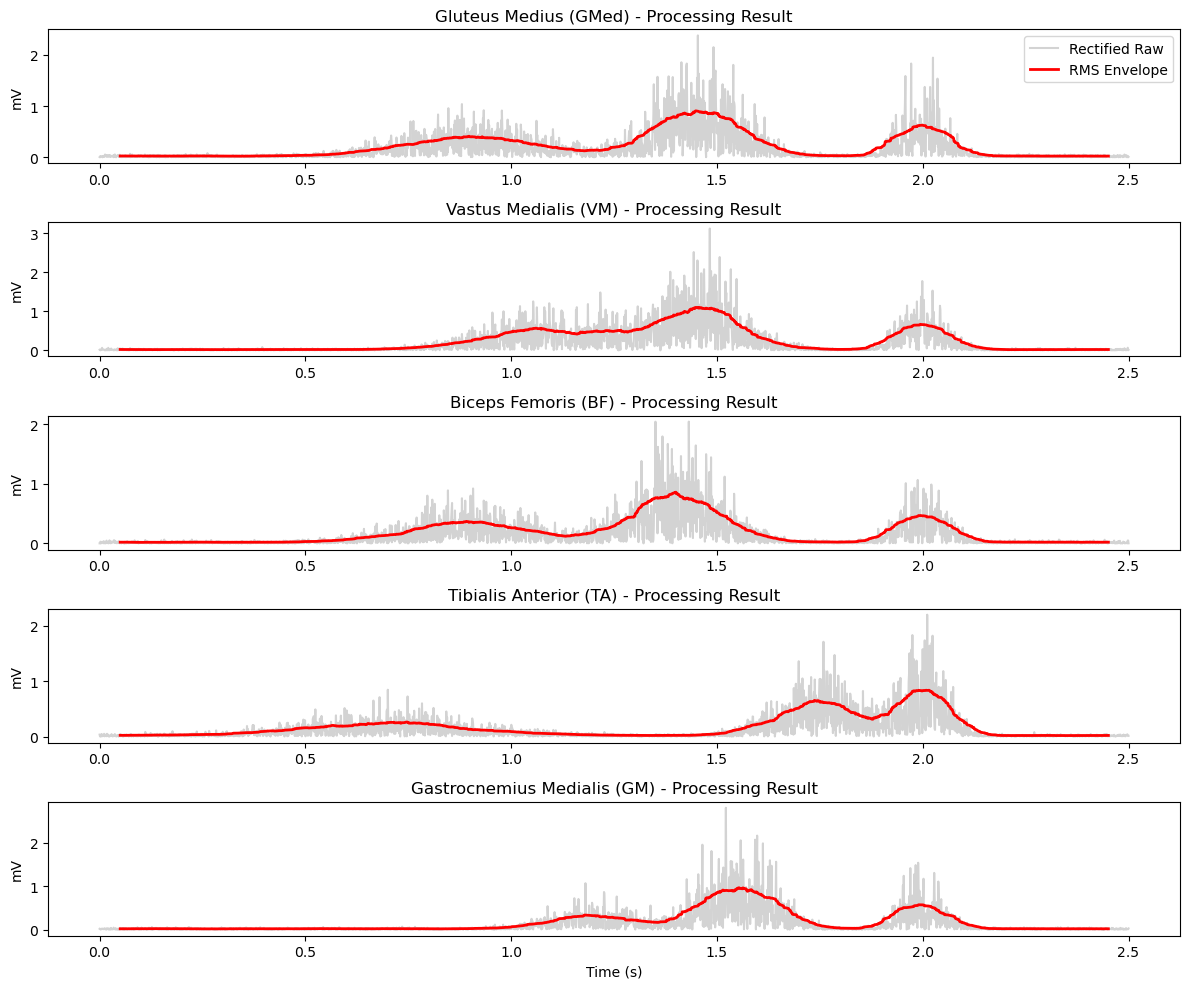


=== 提取的统计指标 (可用于 SPSS 分析) ===
                        Muscle  Peak_RMS_Concentric  Mean_RMS_Concentric
0        Gluteus Medius (GMed)               0.9055               0.6882
1         Vastus Medialis (VM)               1.0993               0.8115
2          Biceps Femoris (BF)               0.8582               0.5815
3       Tibialis Anterior (TA)               0.2231               0.0593
4  Gastrocnemius Medialis (GM)               0.9617               0.5529


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取数据
df = pd.read_csv('CMJ_EMG_Simulated.csv')
time = df['Time (s)']

# 定义一个计算 RMS 的函数 (滑动窗口法)
def calculate_rolling_rms(signal, window_size=50):
    # window_size: 窗口大小，这里假设数据是1000Hz, 50代表50ms
    # 也就是每50个点算一个平方平均数再开根号
    return pd.Series(signal).rolling(window=window_size, center=True).apply(lambda x: np.sqrt(np.mean(x**2)))

# 2. 批量处理所有肌肉
processed_data = pd.DataFrame({'Time (s)': time})
metrics = []

muscle_names = [col for col in df.columns if col != 'Time (s)']

plt.figure(figsize=(12, 10))

for i, muscle in enumerate(muscle_names):
    raw_sig = df[muscle]
    
    # A. 预处理：去直流 (De-mean)
    clean_sig = raw_sig - np.mean(raw_sig)
    
    # B. 平滑：计算 RMS 包络 (窗口宽度 100ms = 100个点)
    rms_envelope = calculate_rolling_rms(clean_sig, window_size=100)
    
    # 保存处理后的数据
    processed_data[muscle + '_RMS'] = rms_envelope
    
    # C. 提取指标 (假设蹬伸阶段是 1.3s 到 1.6s)
    # 找到该阶段的索引
    phase_mask = (time >= 1.3) & (time <= 1.6)
    phase_data = rms_envelope[phase_mask]
    
    peak_val = phase_data.max()
    mean_val = phase_data.mean()
    
    metrics.append({
        'Muscle': muscle,
        'Peak_RMS_Concentric': round(peak_val, 4),
        'Mean_RMS_Concentric': round(mean_val, 4)
    })
    
    # D. 绘图对比：原始信号 vs RMS包络
    plt.subplot(len(muscle_names), 1, i+1)
    plt.plot(time, abs(clean_sig), color='lightgray', label='Rectified Raw') # 灰色背景是原始整流信号
    plt.plot(time, rms_envelope, color='red', linewidth=2, label='RMS Envelope') # 红色线是处理后的包络
    plt.title(f"{muscle} - Processing Result")
    if i == 0: plt.legend(loc='upper right')
    plt.ylabel('mV')

plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

# 3. 输出统计表格 (你可以直接复制这个表格去 SPSS 分析)
metrics_df = pd.DataFrame(metrics)
print("\n=== 提取的统计指标 (可用于 SPSS 分析) ===")
print(metrics_df)